аналоговые,

дискретные,

квантованные,

цифровые

plot() - стандартный график, выводит сигнал в аналоговой форме,

stem() - график в виде отсчетов, выводит сигнал в дискретной форме,

step() - график в виде уровней, выводит сигнал в квантованной форме

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft


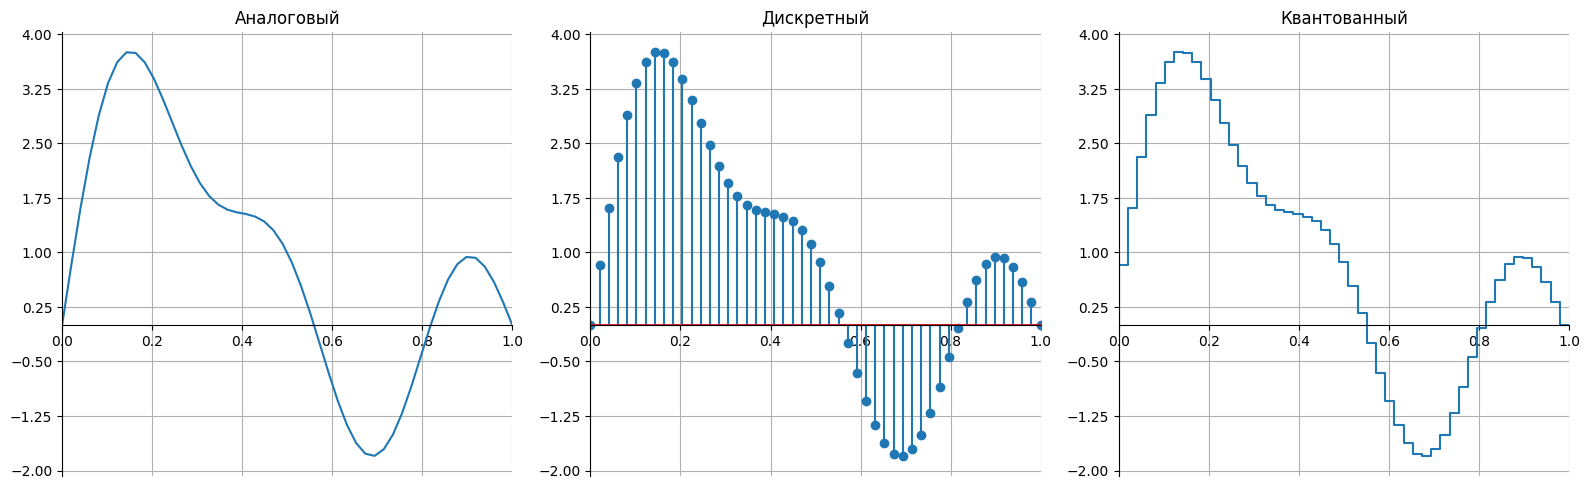

In [ ]:
# time vector
n=50
t = np.linspace(0, 1, n, endpoint=True)
# sine wave
x = np.sin(np.pi*t) + 2*np.sin(2*np.pi*t) + np.sin(3*np.pi*t) + np.sin(5*np.pi*t)

# Select: plot, stem, bar
def plot_selector(s, *args, **kwargs):
    if s == 0:
        return plt.plot(*args)
    if s == 1:
        return plt.stem(*args, **kwargs)
    if s == 2:
        return plt.step(*args)

# Plot figures
fig = plt.figure(figsize=(16, 5), dpi=100)
for i, title in enumerate(['Аналоговый', 'Дискретный', 'Квантованный']):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plot_selector(i, t, x, use_line_collection=True)
    plt.xlim([0, 1])
    plt.yticks(np.linspace(np.floor(np.min(x)), np.ceil(np.max(x)), 9))
    plt.grid(True)

    # change plot view
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position(('data',0))
plt.tight_layout()
plt.show()

In [ ]:
#FFT

import matplotlib.gridspec as gridspec
from scipy.fftpack import fft, ifft, fftshift

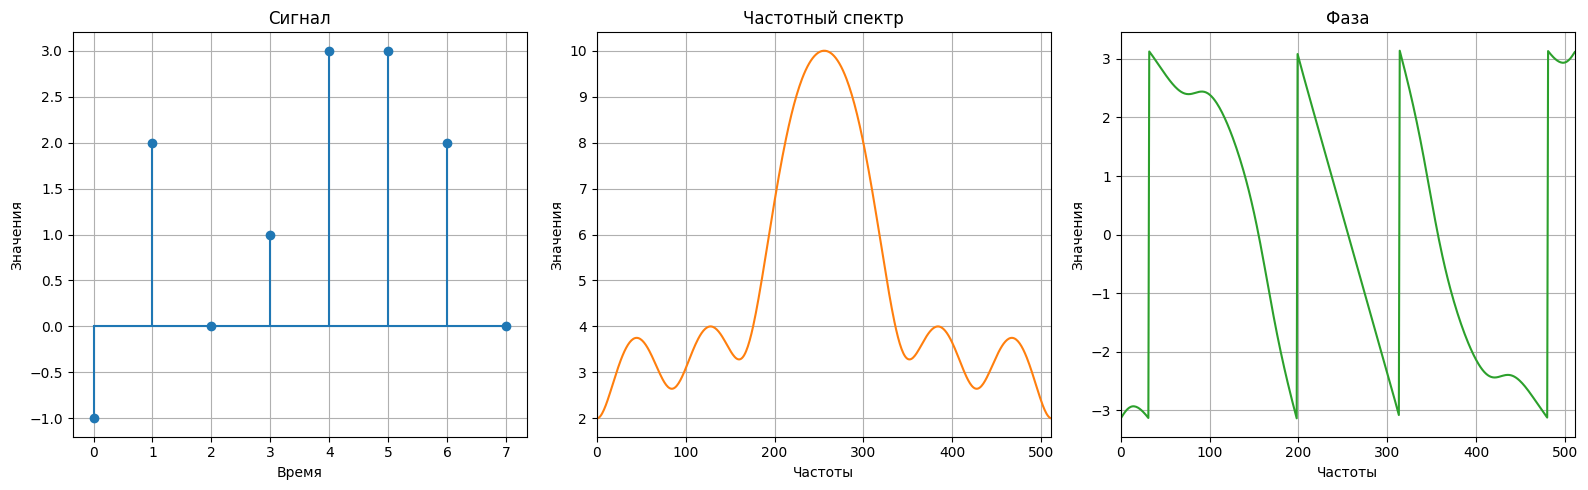

In [ ]:
x = np.array([-1, 2, 0, 1, 3, 3, 2, 0])
# Z-form: X(z) = 1 + 2z^(-1)+z^(-3), where z = exp(-jwT)

# Прямое преобразование Фурье
N = 512

xFFT = fftshift(fft(x, N))
# Частотный спектр
xA = np.abs(xFFT)
# Фаза
xF = np.angle(xFFT)

# List of signals
xT = [x, xA, xF]
lst_title = ['Сигнал', 'Частотный спектр', 'Фаза']

# Plot results
fig = plt.figure(figsize=(16, 5), dpi=100)

for i, sig in enumerate(xT):
    plt.subplot(1, 3, i+1)
    plt.ylabel('Значения')
    plt.title(lst_title[i])
    if i == 0:
        plt.stem(sig, use_line_collection=True, basefmt=f'C0')
        plt.xlabel('Время')
    else:
        plt.plot(sig, f'C{i}')
        plt.xlabel('Частоты')
        plt.xlim([0, N-1])
    plt.grid()
plt.tight_layout()

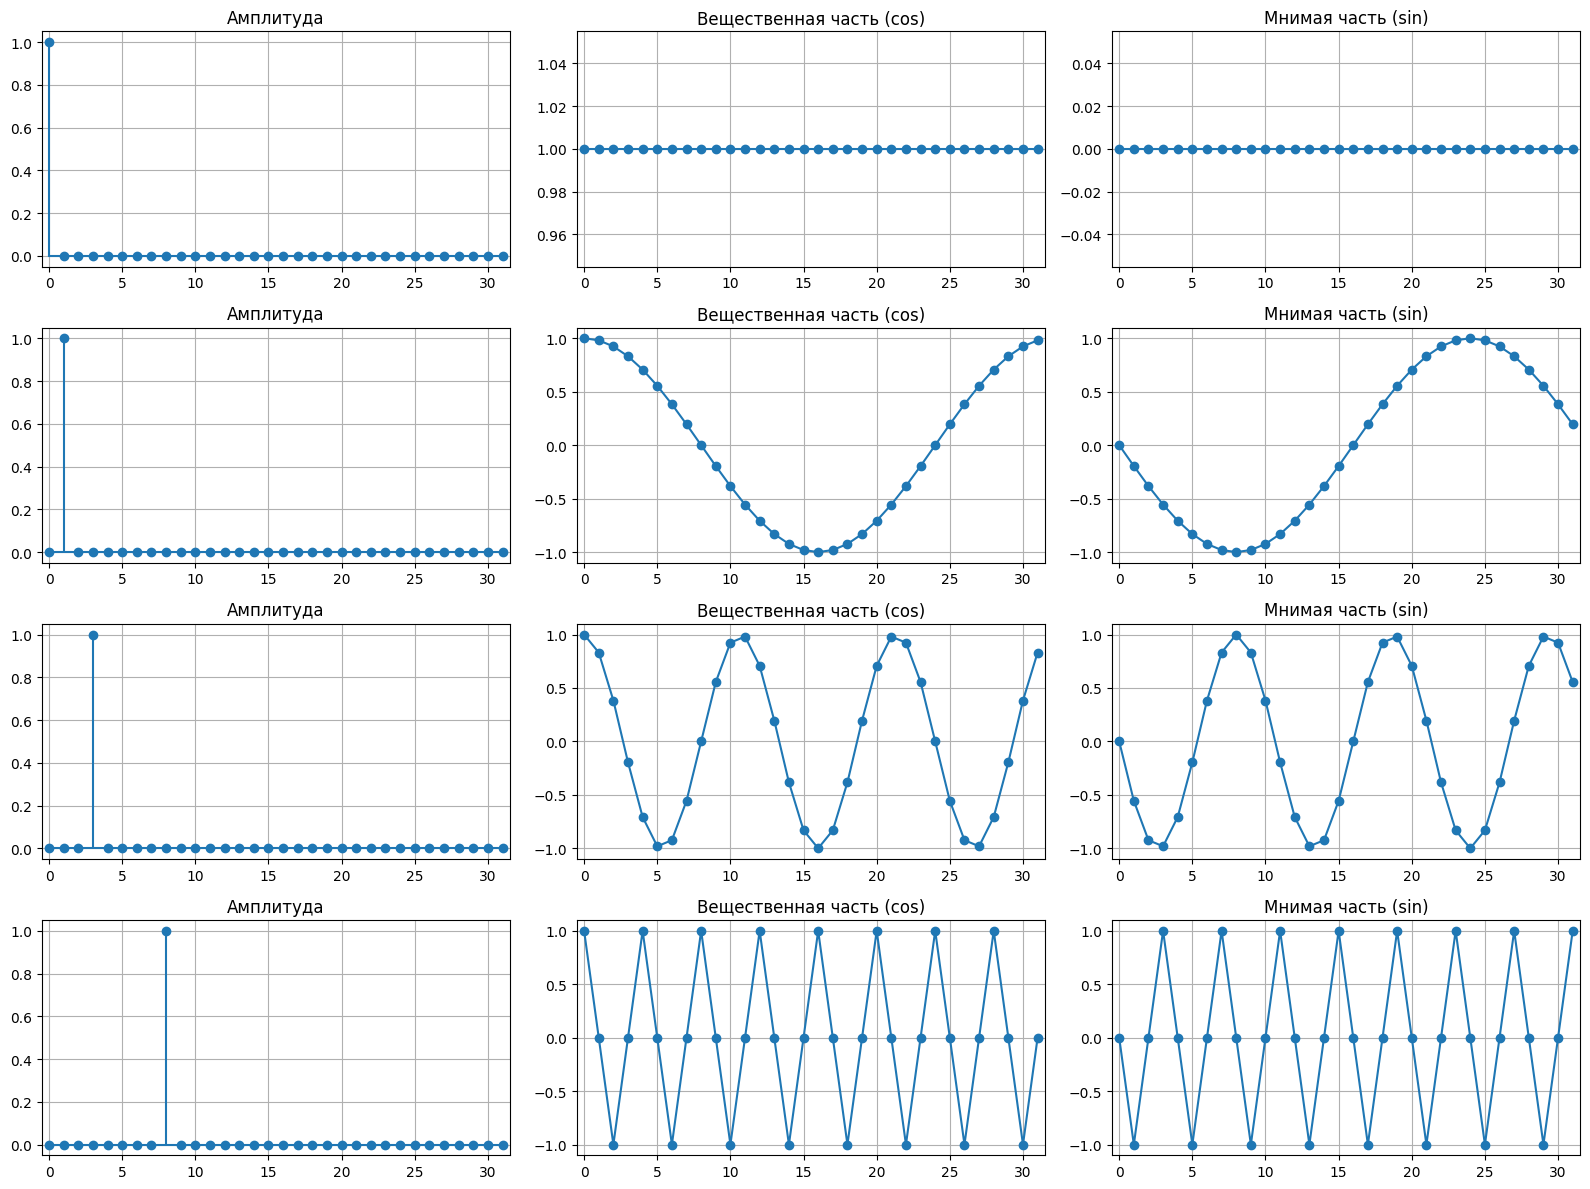

In [ ]:
# Гармонический сигнал
N, M = 32, 4

# Сигнал
x = np.zeros((N,M))
x[0][0] = 1
x[1][1] = 1
x[3][2] = 1
x[8][3] = 1

#  FFT
X = fft(x, axis=0)

# Plot results
fig = plt.figure(figsize=(16, 12), dpi=100)
for i in range(M*3):
    plt.subplot(4, 3, i+1)
    if i % 3 == 0:
        plt.title('Амплитуда')
        plt.stem(x[:,i//3], use_line_collection=True, basefmt='C0')
    if (i-1) % 3 == 0:
        plt.title('Вещественная часть (cos)')
        plt.plot(np.real(X[:,i//3]), '-o')
    if (i-2) % 3 == 0:
        plt.title('Мнимая часть (sin)')
        plt.plot(np.imag(X[:,i//3]), '-o')
    plt.xlim([-0.5, N-0.5])
    plt.xlabel('')
    plt.grid()
plt.tight_layout()

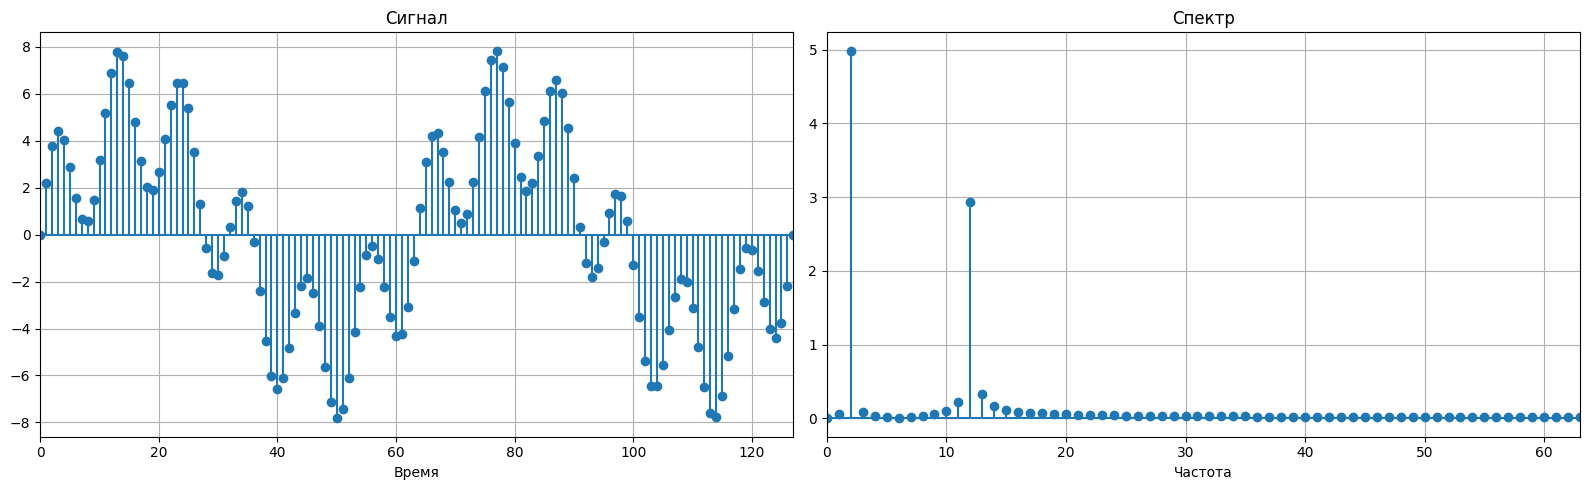

In [ ]:
# Спектр суммы сигналов
N = 128
# Время
t = np.linspace(0, 1, N)

# Амплитуды и частоты
f1, f2, f3 = 2, 7, 12
A1, A2, A3 = 5, 1, 3

# Сигнал
x = A1 * np.sin(2*np.pi*f1*t) + A2 * np.signbit(2*np.pi*f2*t) + A3 * np.sin(2*np.pi*f3*t)

#  FFT
X = fft(x)
X = 2*np.abs(X) / N


fig = plt.figure(figsize=(16, 5), dpi=100)
# Сигнал (Времени)
plt.subplot(1, 2, 1)
plt.title('Сигнал')
plt.stem(x, use_line_collection=True, basefmt='C0')
plt.xlim([0, N-1])
plt.xlabel('Время')
plt.grid()

# Частотный спектр
plt.subplot(1, 2, 2)
plt.title('Спектр')
plt.stem(X, use_line_collection=True, basefmt='C0')
plt.xlim([0, N//2-1])
plt.xlabel('Частота')
plt.grid()
plt.tight_layout()

from scipy.fftpack import *


from scipy.fftpack import fft, ifft, fftshift

fft(x[, n, axis, overwrite_x])	Прямое БПФ

ifft(x[, n, axis, overwrite_x])	Обратное БПФ

fft2(x[, shape, axes, overwrite_x])	Двумерное прямое БПФ

ifft2(x[, shape, axes, overwrite_x])	Двумерное обратное БПФ

fft2(x[, shape, axes, overwrite_x])	Многомерное прямое БПФ

ifft2(x[, shape, axes, overwrite_x])	Многомерное обратное БПФ

rfft(x[, n, axis, overwrite_x])	Прямое БПФ вещественного сигнала

irfft(x[, n, axis, overwrite_x])	Обратное БПФ вещественного сигнала

dct(x[, type, n, axis, norm, overwrite_x])	Прямое косинусное ПФ

idct(x[, type, n, axis, norm, overwrite_x])	Обратное косинусное ПФ

dctn(x[, type, shape, axes, norm, overwrite_x])	Многомерное прямое косинусное ПФ

idctn(x[, type, shape, axes, norm, overwrite_x])	Многомерное обратное косинусное БПФ

dst(x[, type, n, axis, norm, overwrite_x])	Прямое синусное ПФ

idst(x[, type, n, axis, norm, overwrite_x])	Обратное синусное ПФ

dstn(x[, type, shape, axes, norm, overwrite_x])	Многомерное прямое синусное ПФ

idstn(x[, type, shape, axes, norm, overwrite_x])	Многомерное обратное синусное БПФ

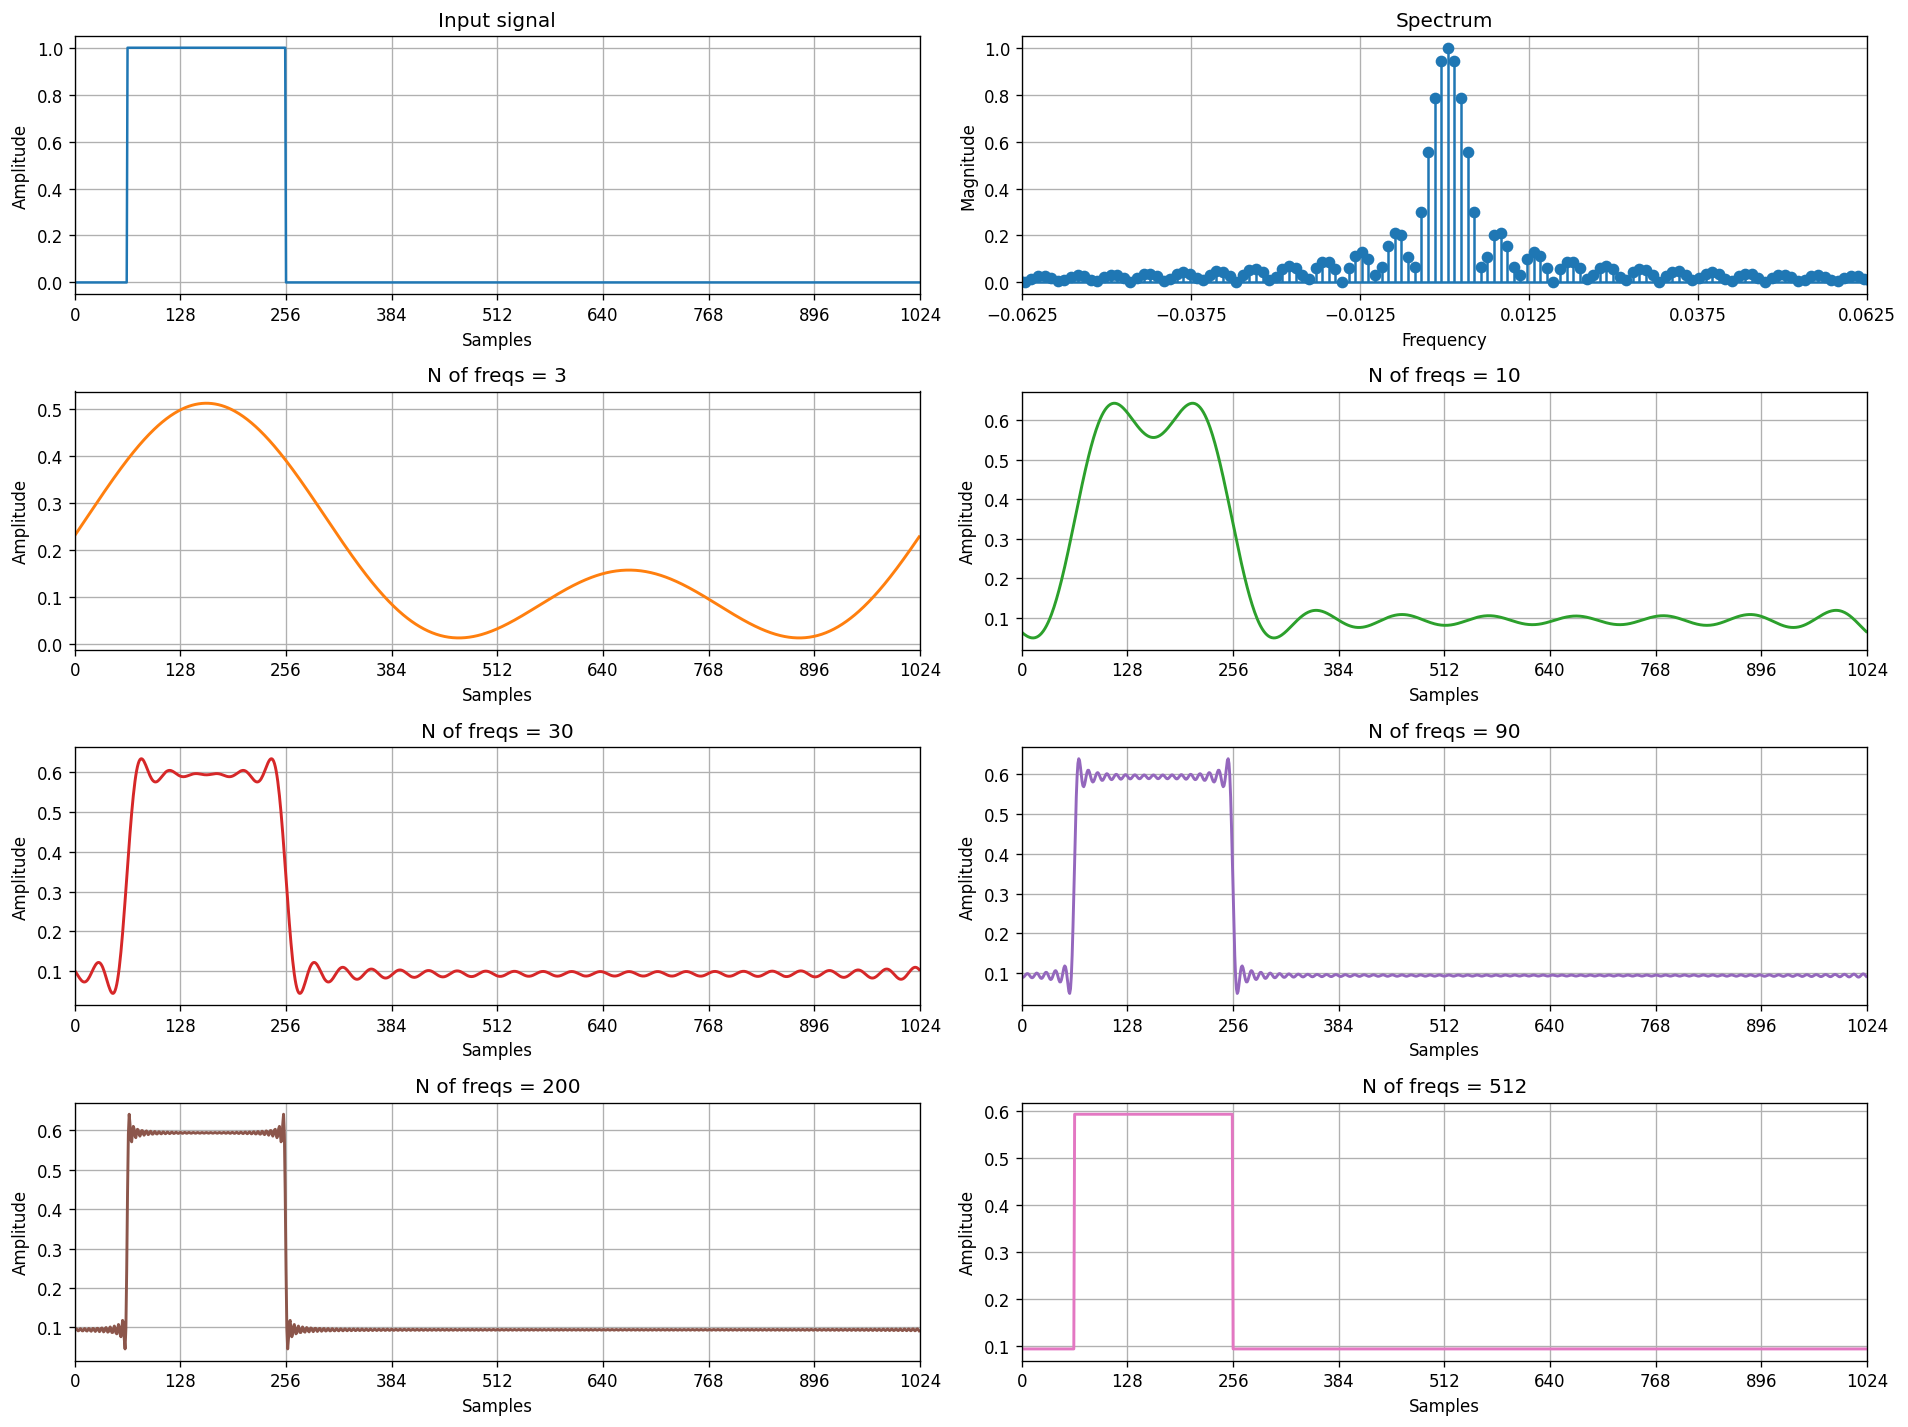

In [ ]:
N = 1024
# Create input signal
x = np.zeros(N)
x[64:256] = 1

# Find Forward FFT
X = fft(x, N)
# Normalized shifted spectrum
Xs = fftshift(np.abs(X))
Xs /= np.max(Xs)
# Normalized frequency
f = np.linspace(-0.5, 0.5, N, endpoint=True)

# Plot input signal in time domain
plt.figure(figsize=(16, 12), dpi=120)
plt.subplot(4, 2, 1)
plt.plot(x)
plt.title('Input signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.xlim([0, N-1])
plt.xticks(np.linspace(0, N, 9, endpoint=True))
plt.grid()

# Plot signal in freq domain
plt.subplot(4, 2, 2)
plt.stem(f, Xs, use_line_collection=True, basefmt='C0')
plt.title('Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.xlim([-1/16, 1/16])
plt.xticks(np.linspace(-1/16, 1/16, 6, endpoint=True))
plt.grid()

# Set the list - number of harmonics
l_freqs = (3, 10, 30, 90, 200, N//2)

# Plot signal with several
for i, j in enumerate(l_freqs):
    plt.subplot(4, 2, i+3)
    K = X.copy()
    K[j:] = 0
    k = np.real(ifft(K))
    plt.plot(k, color='C'+str(i+1), linewidth=1.75)
    plt.title(f'N of freqs = {j}')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.xlim([0, N-1])
    plt.xticks(np.linspace(0, N, 9, endpoint=True))
    plt.grid()
plt.tight_layout()
plt.savefig("fig1_gibbs.png")

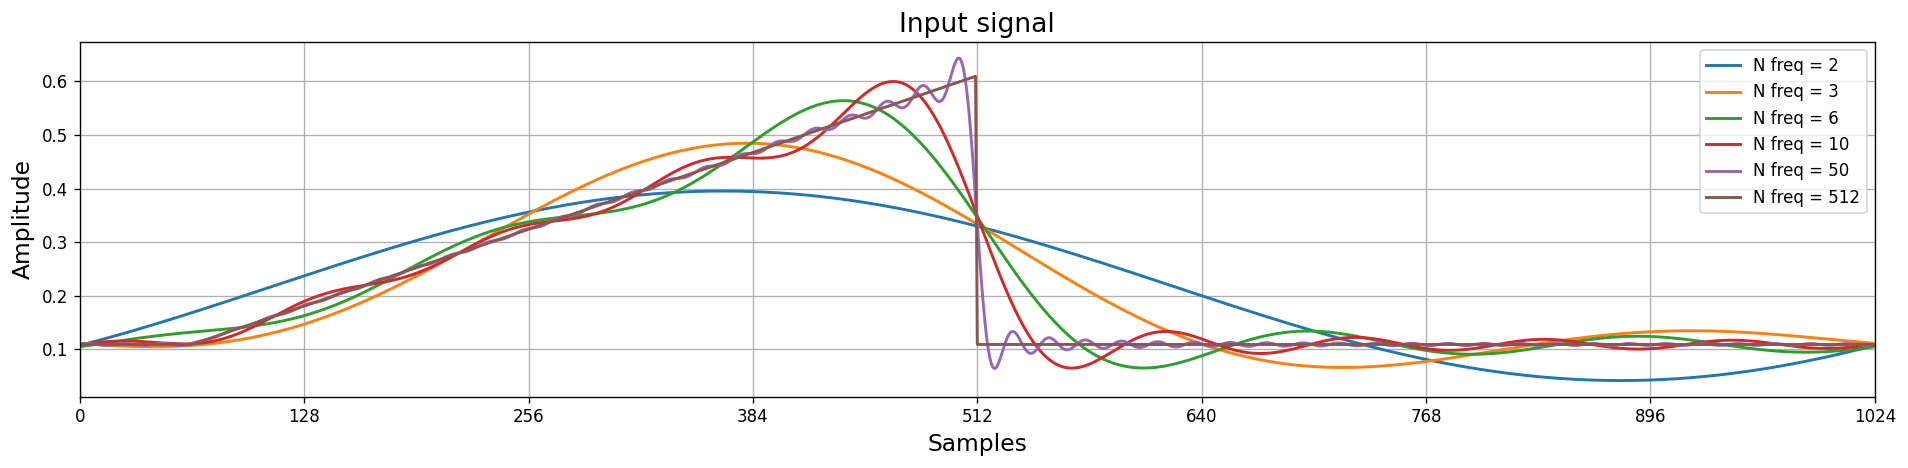

In [ ]:
N = 1024
# Create input signal
x = np.zeros(N)
x[64:512] = np.linspace(0, 1, 512-64)

# Find Forward FFT
X = fft(x, N)

# Set the list - number of harmonics
l_freqs = (2, 3, 6, 10, 50, N//2)

# Plot signal with several
plt.figure(figsize=(16, 4), dpi=120)
plt.title('Input signal', fontsize=16)
plt.xlabel('Samples', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.xlim([0, N-1])
plt.xticks(np.linspace(0, N, 9, endpoint=True))
for i, j in enumerate(l_freqs):
    K = X.copy()
    K[j:] = 0
    k = np.real(ifft(K))
    plt.plot(k, color='C'+str(i), linewidth=1.75, label='N freq = {}'.format(l_freqs[i]))
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("fig2_gibbs.png")

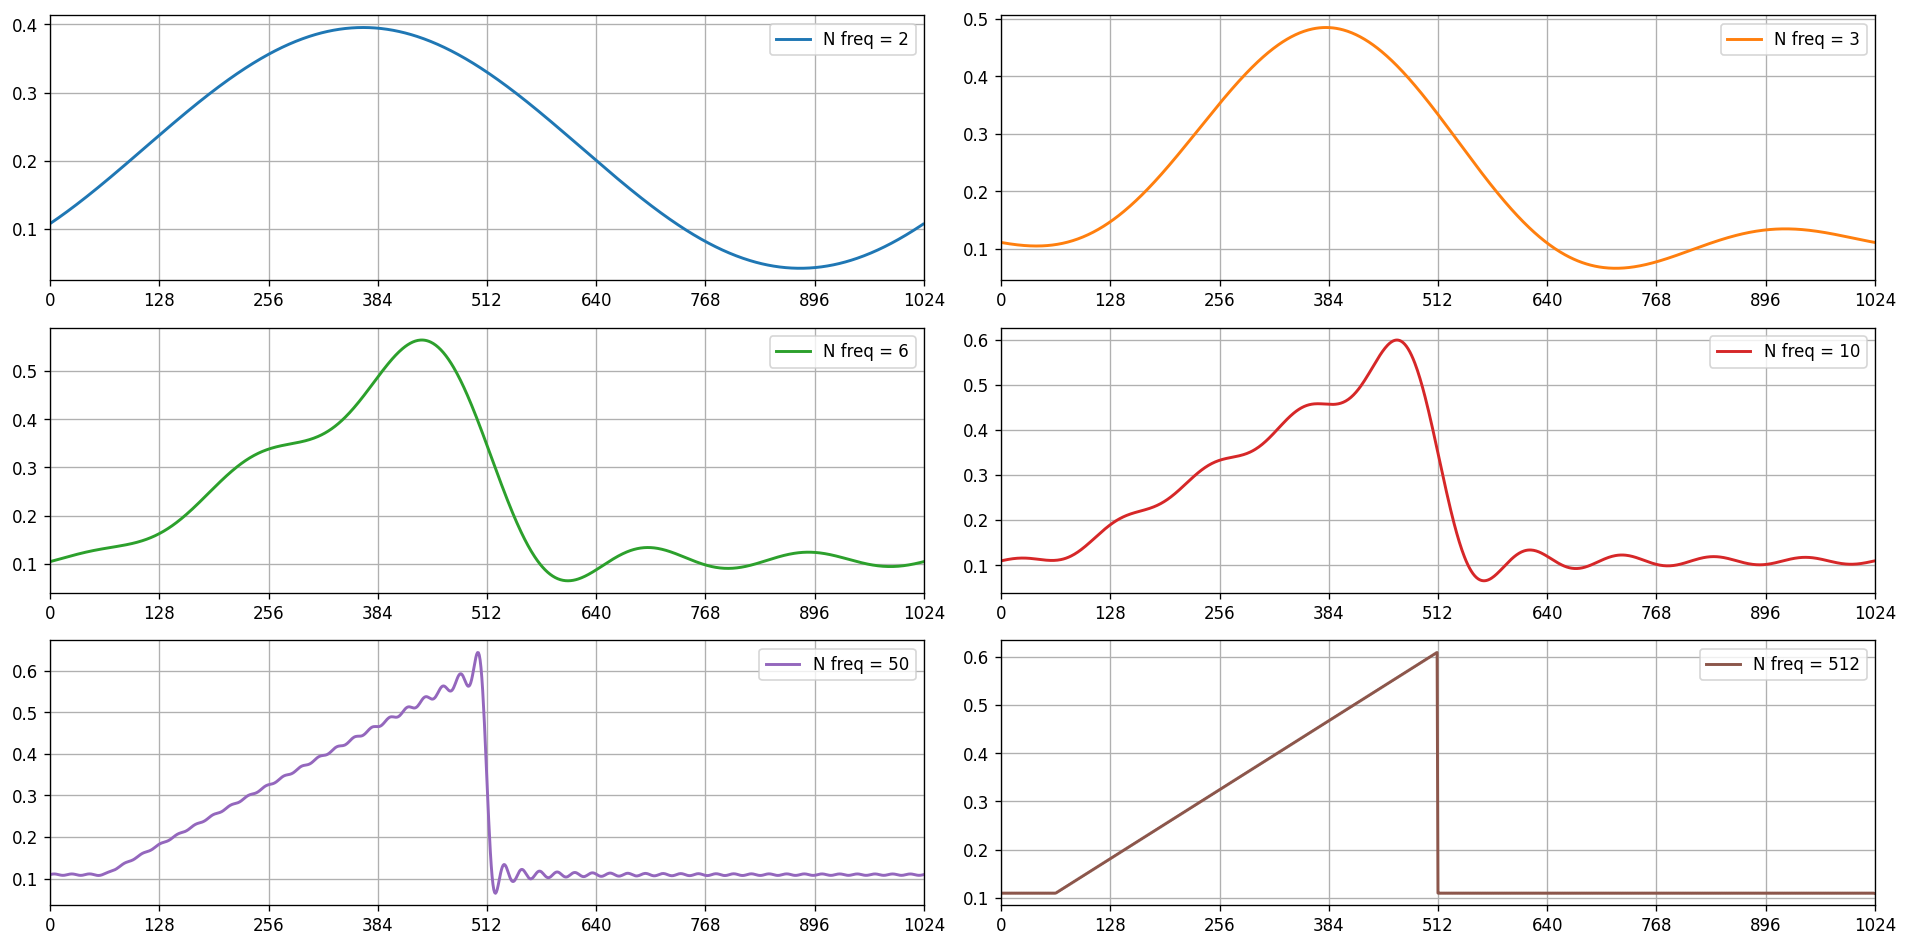

In [ ]:
plt.figure(figsize=(16, 8), dpi=120)
plt.title('Input signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')

for i, j in enumerate(l_freqs):
    K = X.copy()
    K[j:] = 0
    k = np.real(ifft(K))
    plt.subplot(3, 2, i+1)
    plt.plot(k, color='C'+str(i), linewidth=1.75, label='N freq = {}'.format(l_freqs[i]))
    plt.xlim([0, N-1])
    plt.xticks(np.linspace(0, N, 9, endpoint=True))

    plt.grid()
    plt.legend()
plt.tight_layout()
plt.savefig("fig3_gibbs.png")

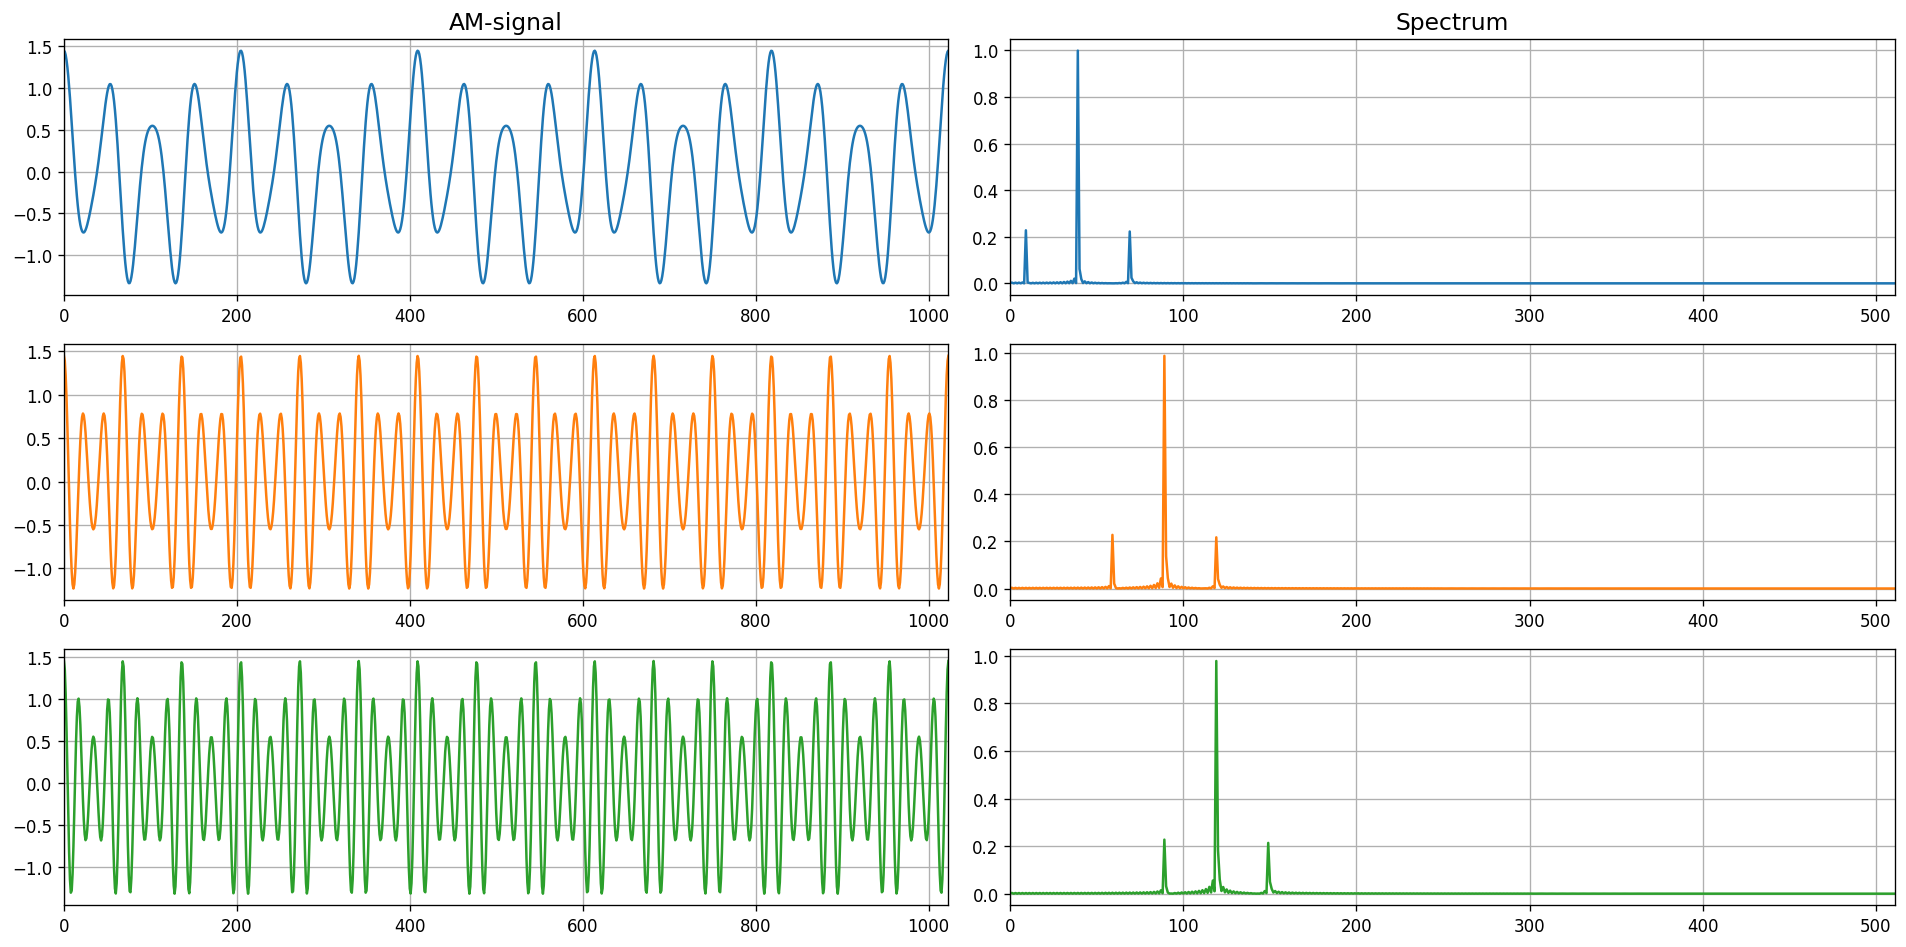

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, rfft, fftshift

%matplotlib inline

#Модуляция
def signal_am(amp=1.0, km=0.25, fc=10.0, fs=2.0, period=100):
    """
    Create Amplitude modulation (AM) signal

    Parameters
    ----------
    amp : float
        Signal magnitude
    km : float
        Modulation coeff: amplitude sensitivity 0 <= km < 1
    fc : float
        Carrier frequency
    fs : float
        Signal frequency
    period : integer
        Number of points for signal (same as period)
    """
    tt = 2.0 * np.pi * np.linspace(0, 1, period)
    return amp * (1 + km * np.cos(fs * tt)) * np.cos(fc * tt)
N = 1024

# Create AM-signal
fs = 15             # Modulation frequency
fc = [20, 45, 60]   # Carrier frequency

sig = [signal_am(amp=1.0, km=0.45, fc=i, fs=fs, period=N) for i in fc]

# Calculate FFT
sft = np.abs(rfft(sig, axis=1)) / N / 0.5

plt.figure(figsize=(16, 8), dpi=120)
for i, freq in enumerate(fc):
    plt.subplot(len(fc), 2, 2*i+1)
    if i == 0:
        plt.title('AM-signal', fontsize=14)
    plt.plot(sig[i], color=f"C{i}")
    plt.xlim([0, N-1])
    plt.grid(True)

    plt.subplot(len(fc), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum', fontsize=14)
    plt.plot(sft[i], color=f"C{i}")
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

Модуляцией называется процесс изменения одного или нескольких параметров сигнала. Модулируемый сигнал называется "несущим" (на частоте этого сигнала передается модулируемое сообщение). Информационный сигнал называется модулирующим. Как правило, модулирующий сигнал - низкочастотный, а несущий сигнал - высокочастотный. В процессе модуляции несущего сигнала спектр модулирующего сигнала переносится в область несущей частоты. Гармонические сигналы можно модулировать во времени по амплитуде, частоте и фазе.
Изменяется расстояние между центральной (несущей) частотой и боковыми (модулирующими) частотами.

Ширина спектра АМ сигнала равна удвоенной частоте модулирующего сигнала.

In [ ]:
!wget http://top-formula.net/wp-content/uploads/2017/11/6.1.jpg

--2021-02-22 12:13:03--  http://top-formula.net/wp-content/uploads/2017/11/6.1.jpg
Resolving top-formula.net (top-formula.net)... 195.208.1.107
Connecting to top-formula.net (top-formula.net)|195.208.1.107|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 107634 (105K) [image/jpeg]
Saving to: ‘6.1.jpg’

6.1.jpg             100%[===================>] 105.11K   119KB/s    in 0.9s    

2021-02-22 12:13:05 (119 KB/s) - ‘6.1.jpg’ saved [107634/107634]



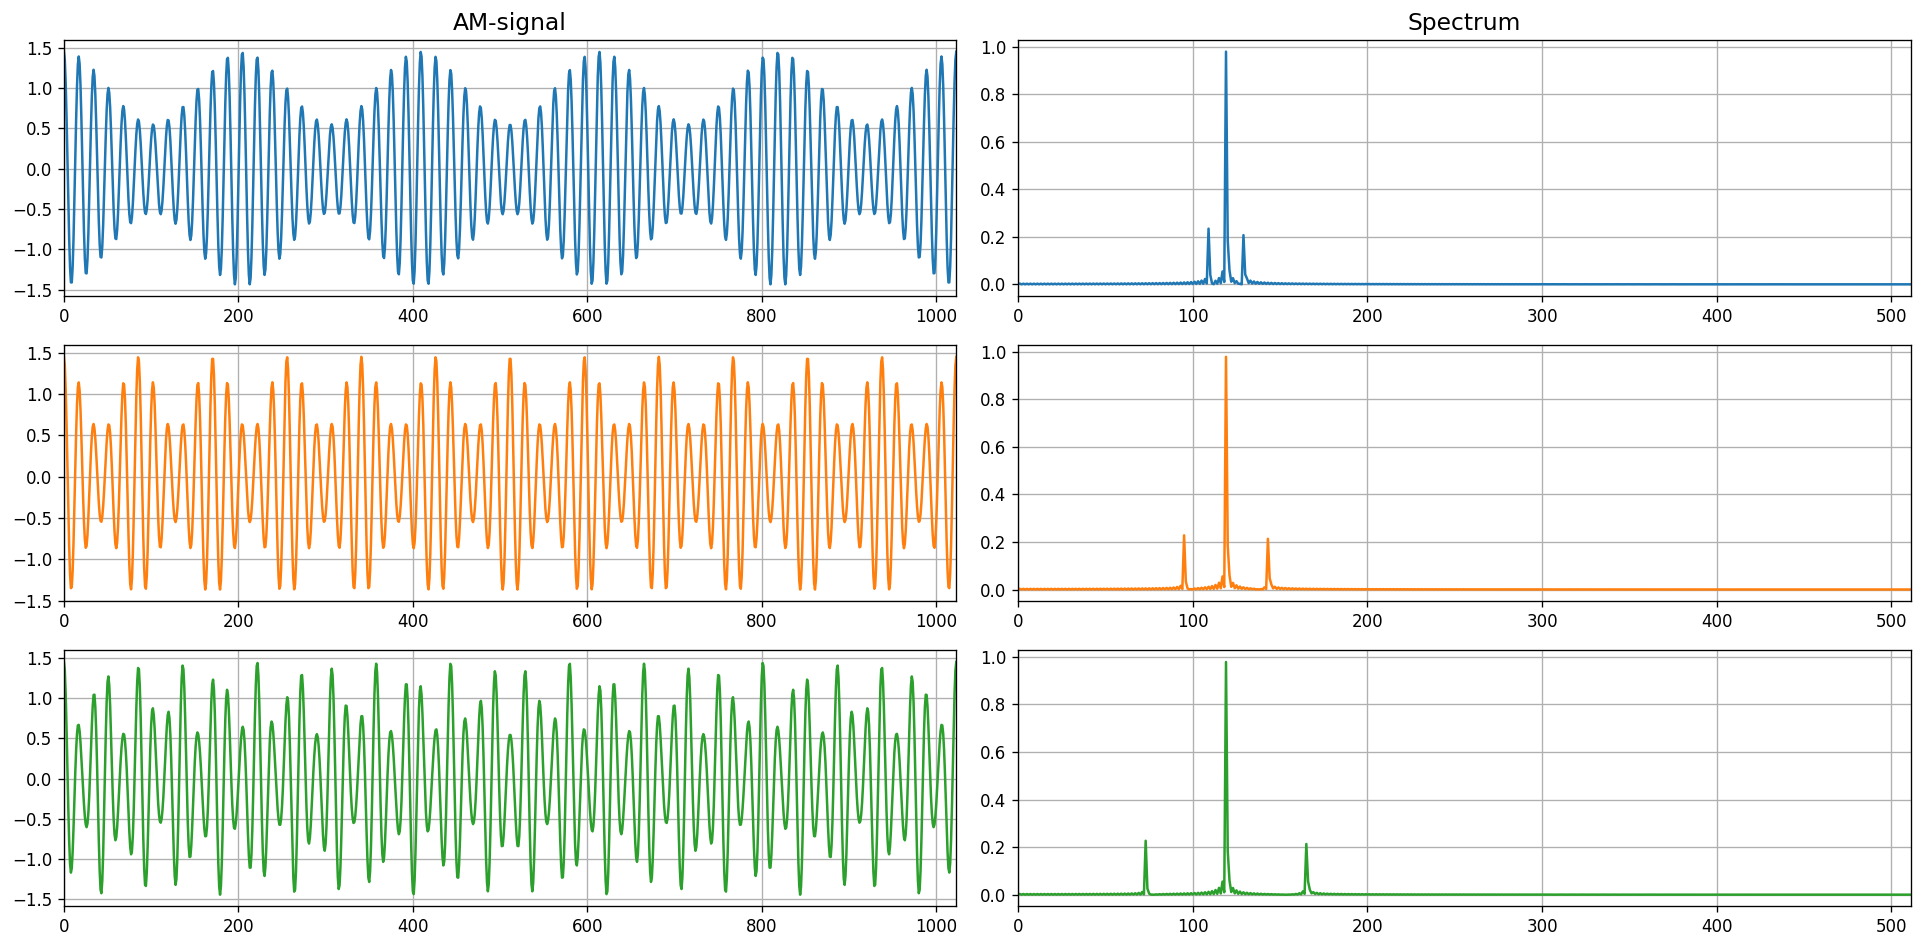

In [ ]:
N = 1024
# Create AM-signal
fs = [5, 12, 23]    # Modulation frequency
fс = 60             # Carrier frequency

sig = [signal_am(amp=1.0, km=0.45, fc=fс, fs=i, period=N) for i in fs]

# Calculate FFT
sft = np.abs(rfft(sig, axis=1)) / N / 0.5

plt.figure(figsize=(16, 8), dpi=120)
for i, freq in enumerate(fs):
    plt.subplot(len(fc), 2, 2*i+1)
    if i == 0:
        plt.title('AM-signal', fontsize=14)
    plt.plot(sig[i], color=f"C{i}")
    plt.xlim([0, N-1])
    plt.grid(True)

    plt.subplot(len(fs), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum', fontsize=14)
    plt.plot(sft[i], color=f"C{i}")
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

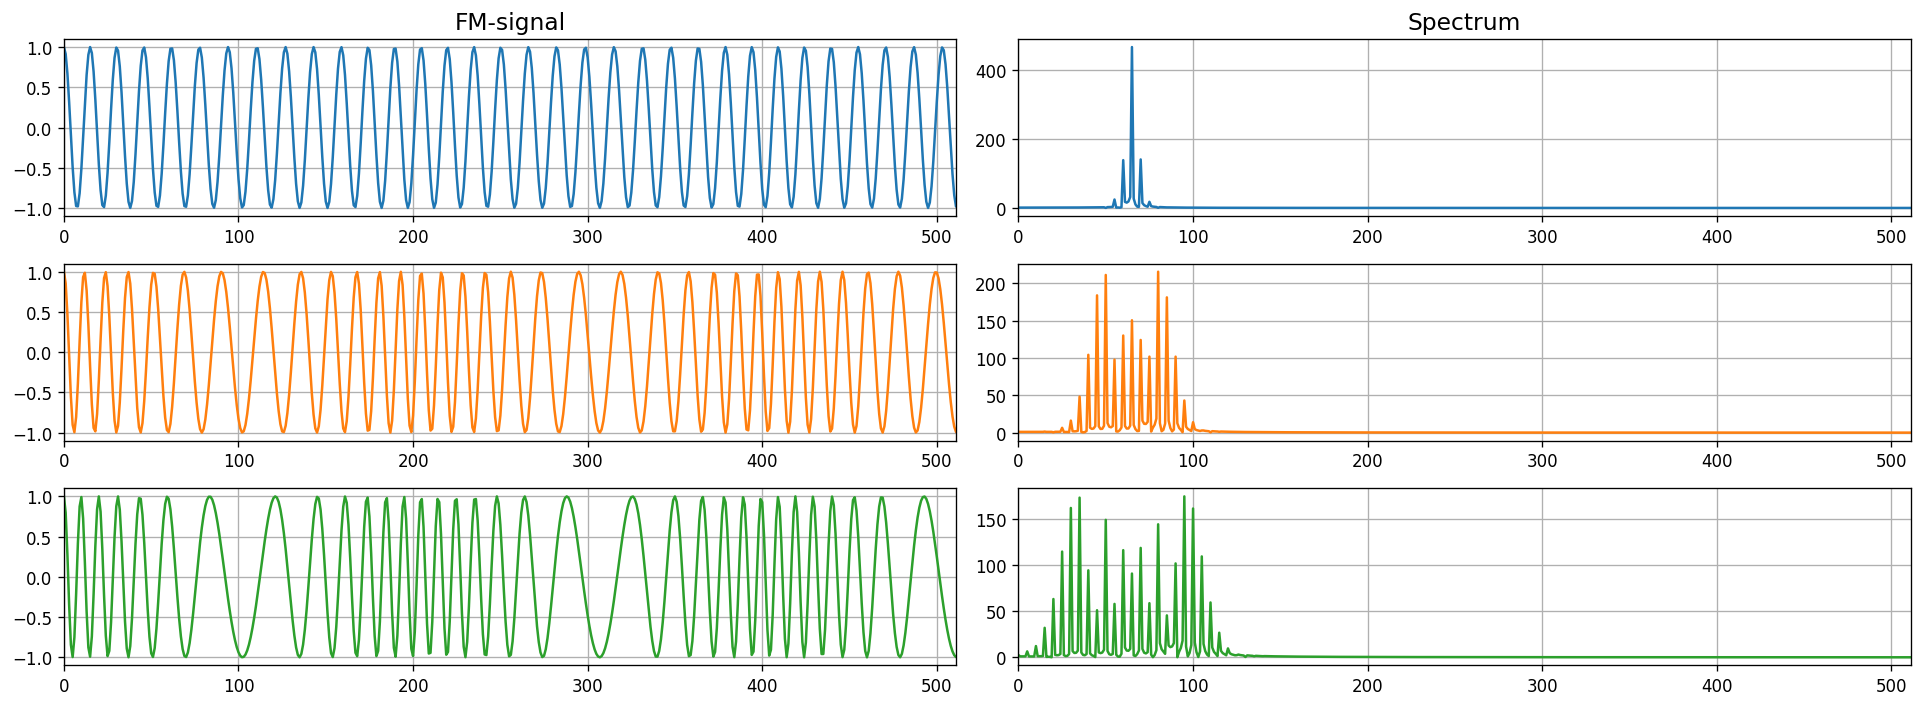

In [ ]:
def signal_fm(amp=1.0, kd=0.25, fc=10.0, fs=2.0, period=100):
    """
    Create Frequency modulation (FM) signal

    Parameters
    ----------
    amp : float
        Signal magnitude
    kd : float
        Frequency deviation, kd < period/4,
        e.g. fc = 0, fs = 1, kd = 16
    fc : float
        Carrier frequency
    fs : float
        Signal frequency
    period : integer
        Number of points for signal (same as period)
    """
    tt = 2.0 * np.pi * np.linspace(0, 1, period)
    return amp * np.cos(fc * tt + kd/fs * np.sin(fs * tt))

N = 1024
fs = 5            # Modulation frequency
fс = 65           # Carrier frequency
kd = [3, 23, 40]  # modulation coeff.

sig = [signal_fm(amp=1.0, kd=i, fc=fс, fs=fs, period=N) for i in kd]

# Calculate FFT
sft = np.abs(fft(sig, axis=1))

plt.figure(figsize=(16, 6), dpi=120)
for i, freq in enumerate(kd):
    plt.subplot(len(kd), 2, 2*i+1)
    if i == 0:
        plt.title('FM-signal', fontsize=14)
    plt.plot(sig[i], color=f"C{i}")
    plt.xlim([0, N//2-1])
    plt.grid(True)

    plt.subplot(len(kd), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum', fontsize=14)
    plt.plot(sft[i], color=f"C{i}")
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

**Фильтры**
iirdesign(wp, ws, gpass, gstop[, analog, ...])	Функция для полного расчёта цифрового фильтра. Возвращает коэффициенты a, b, нули и полюсы и т.д.

iirfilter(N, Wn[, rp, rs, btype, analog, ...])	Реализация БИХ-фильтра выбранного типа и N-порядка. Возвращает коэффициенты a, b, нули и полюсы и т.д.

butter(N, Wn[, btype, analog, output, fs])	Фильтр Баттерворта. Реализует фильтр N-порядка и возвращает коэффициенты фильтра.

buttord(wp, ws, gpass, gstop[, analog, fs])	Возвращает минимальный порядок, требуемый для реализации фильтра

cheby1(N, rp, Wn[, btype, analog, output, fs])	Фильтр Чебышева 1 типа. Реализует фильтр N-порядка и возвращает коэффициенты фильтра.

cheb1ord(wp, ws, gpass, gstop[, analog, fs])	Возвращает минимальный порядок, требуемый для реализации фильтра

cheby2(N, rs, Wn[, btype, analog, output, fs])	Фильтр Чебышева 2 типа. Реализует фильтр N-порядка и возвращает коэффициенты фильтра.

cheb2ord(wp, ws, gpass, gstop[, analog, fs])	Возвращает минимальный порядок, требуемый для реализации фильтра

ellip(N, rp, rs, Wn[, btype, analog, output, fs])	Эллиптический БИХ-фильтр (Кауэра)

ellipord(wp, ws, gpass, gstop[, analog, fs])	Возвращает минимальный порядок, требуемый для реализации фильтра от значений входных аргументов

bessel(N, Wn[, btype, analog, output, norm, fs])	БИХ-фильтр Бесселя.

iirnotch(w0, Q[, fs])	Заграждающий фильтр. Возвращает коэффициенты a, b. Входные аргументы - частота сигнала, добротность и частота среза

iirpeak(w0, Q[, fs])	Полосовой фильтр. Функция возвращает коэффициенты a, b
фильтра второго порядка. Входные аргументы - частота сигнала, добротность и частота среза

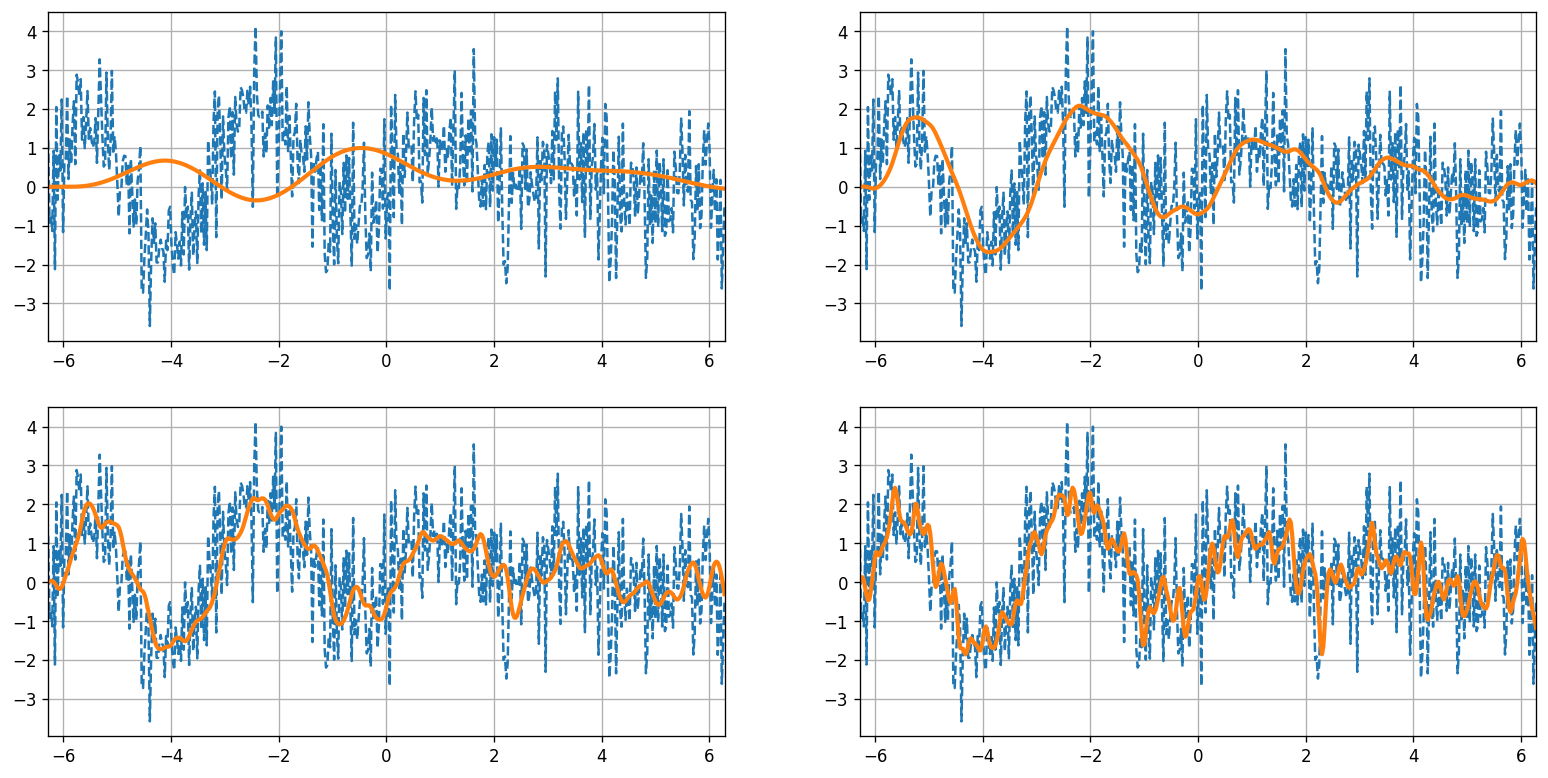

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz, butter, firls, remez, firwin, firwin2, group_delay
from scipy.fftpack import fft, fftshift
#фильтра Баттерворта 3 порядка
# Create input signal
t = 2 * np.pi * np.linspace(-1, 1, 500)
x = np.sin(0.25*t*t)+ 0.95*np.sin(2.0*t)

# Add some white noise
np.random.seed(1)
xn = x + np.random.randn(len(t))

# 3-order lowpass butterworth filter
b, a = butter(3, 0.2)
z = lfilter(b, a, xn)

wn = [0.01, 0.05, 0.1, 0.2]

# Calculate IIR filter
zz = np.zeros((t.size, 4))
for i in range(4):
    b, a = butter(3, wn[i])
    zz[:, i] = lfilter(b, a, xn)

# Plot results
plt.figure(figsize=(16, 8), dpi=120)
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(t, xn, 'C0--', linewidth=1.5)
    plt.plot(t, zz[:,i], 'C1', linewidth=2.5)
    plt.xlim([-2 * np.pi, 2 * np.pi])
    plt.grid(True)

**Основные оконные функции**

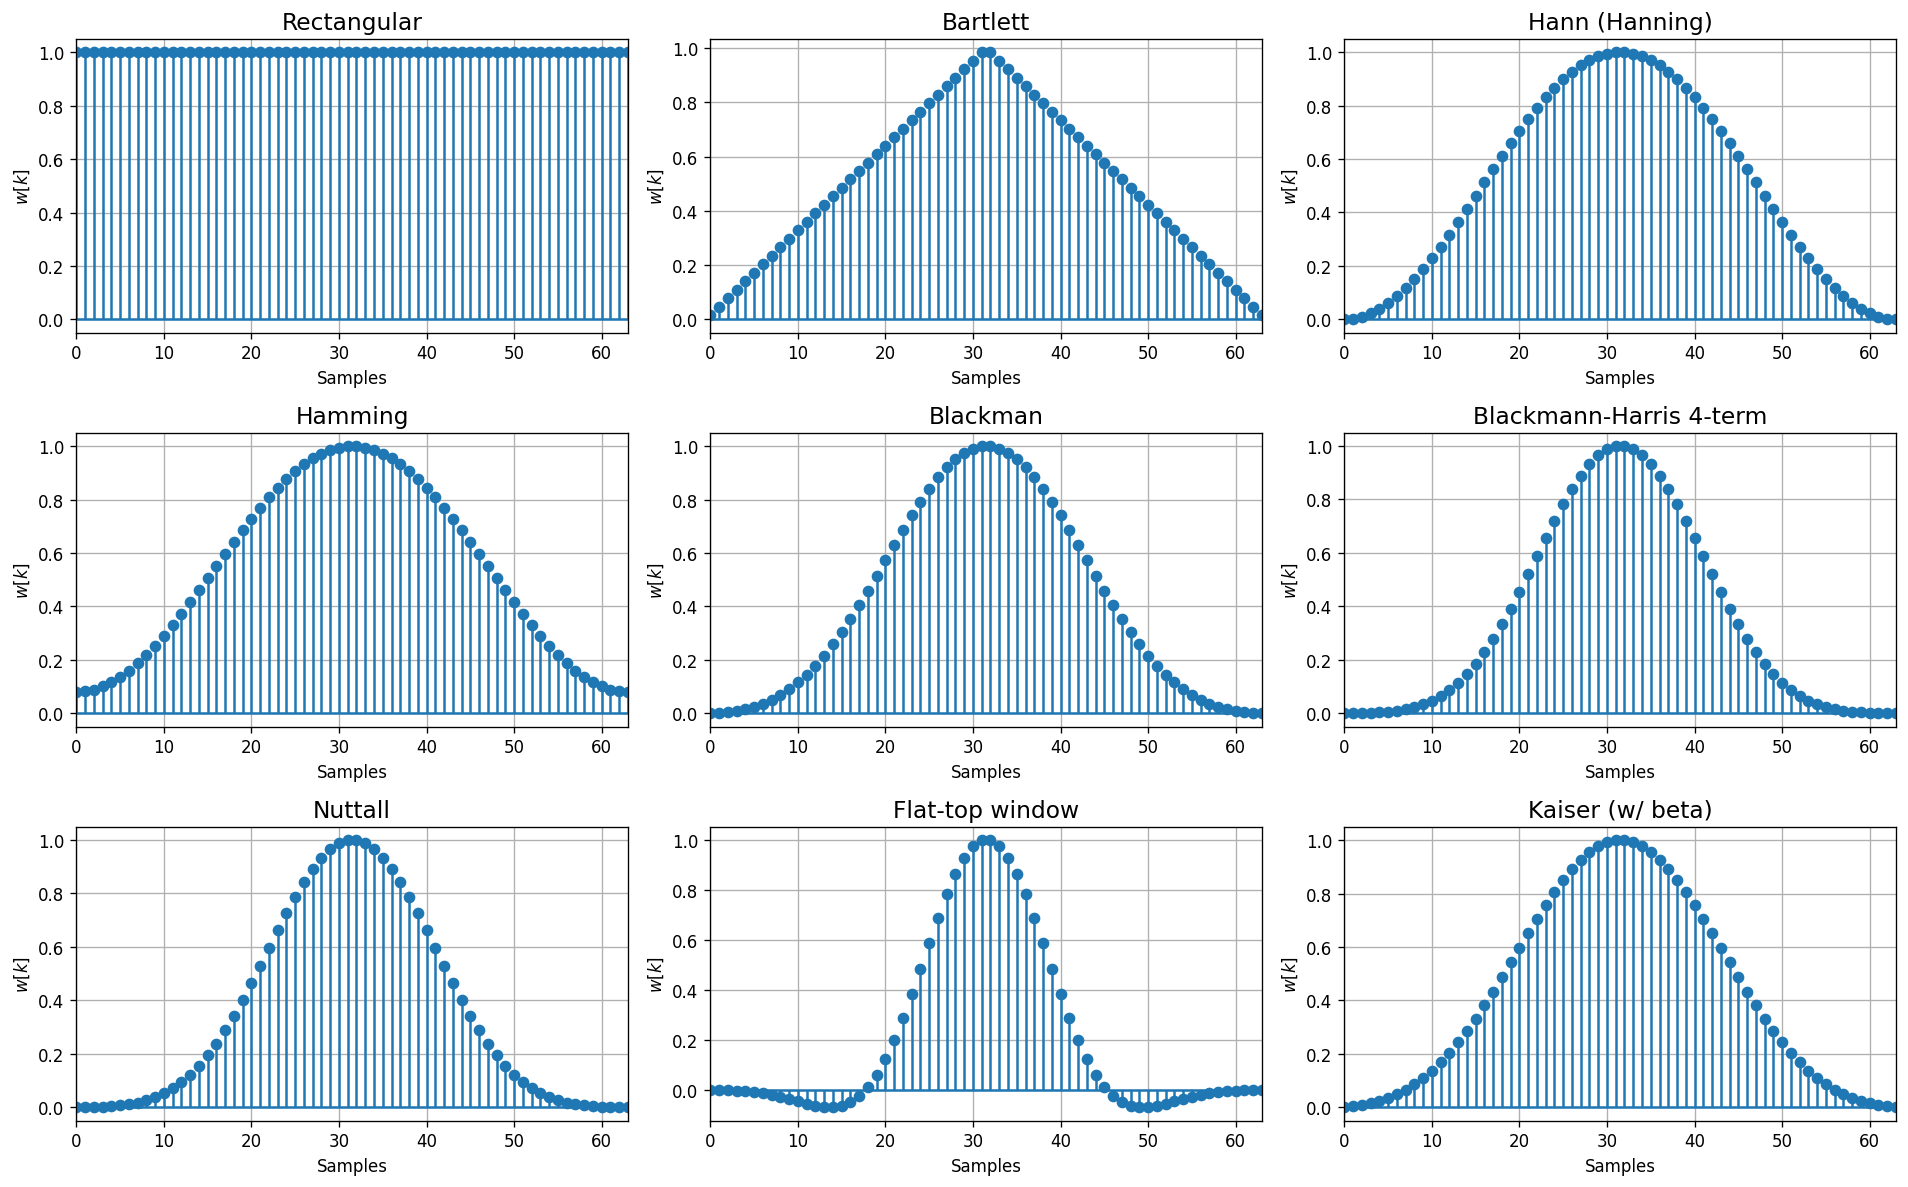

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift
import scipy.signal as sig
N = 64
# All windows
ww = np.zeros((N, 9))

ww[:,0] = np.ones(N)
ww[:,1] = sig.triang(N)
ww[:,2] = sig.hann(N)
ww[:,3] = sig.hamming(N)
ww[:,4] = sig.blackman(N)
ww[:,5] = sig.blackmanharris(N)
ww[:,6] = sig.nuttall(N)
ww[:,7] = sig.flattop(N)
ww[:,8] = sig.kaiser(N, beta=8)

lst_titles = ['Rectangular', 'Bartlett', 'Hann (Hanning)',
              'Hamming', 'Blackman', 'Blackmann-Harris 4-term',
              'Nuttall', 'Flat-top window', 'Kaiser (w/ beta)'
             ]

# Plot window function and its spectrum
fig = plt.figure(figsize=(16, 10), dpi=120)
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.stem(ww[:,i], use_line_collection=True, basefmt='C0')
    plt.title(lst_titles[i], fontsize=14)
    plt.xlabel('Samples')
    plt.ylabel(r'$w[k]$')
    plt.xlim([0, N-1])
    plt.grid(True)
plt.tight_layout()

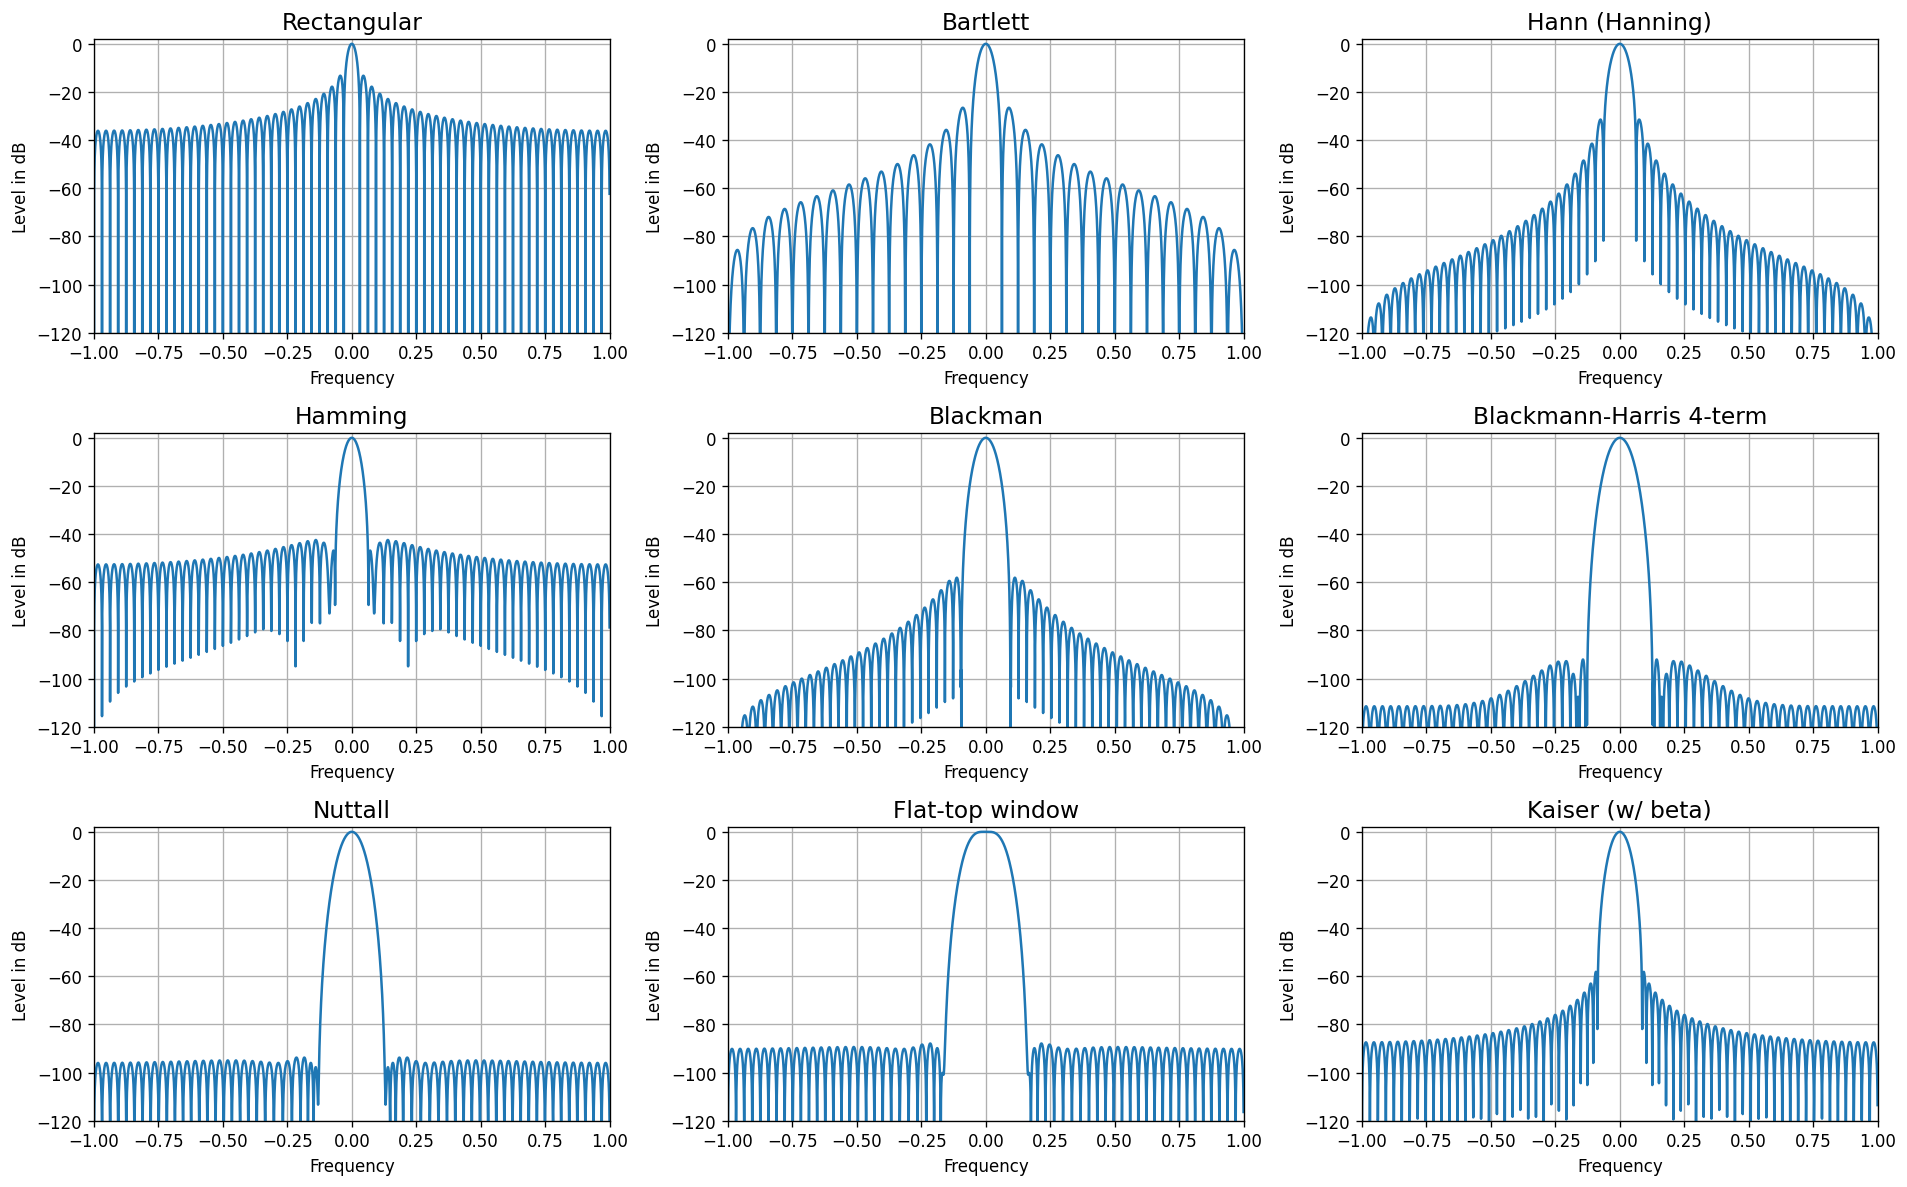

In [ ]:
# спектры
NFFT = 2**12
# Calculate FFT
WW = fft(ww, NFFT, axis=0)
WW = WW / np.amax(WW, axis=0) + np.nextafter(0,1)

tt = np.linspace(-1, 1, NFFT)

# Plot window function and its spectrum
fig2 = plt.figure(figsize=(16, 10), dpi=120)
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.plot(tt, 20*np.log10(np.abs(fftshift(WW[:,i]))))
    plt.title(lst_titles[i], fontsize=14)
    plt.xlabel('Frequency')
    plt.ylabel('Level in dB')
    plt.axis([-1, 1, -120, 2])
    plt.grid(True)

plt.tight_layout()

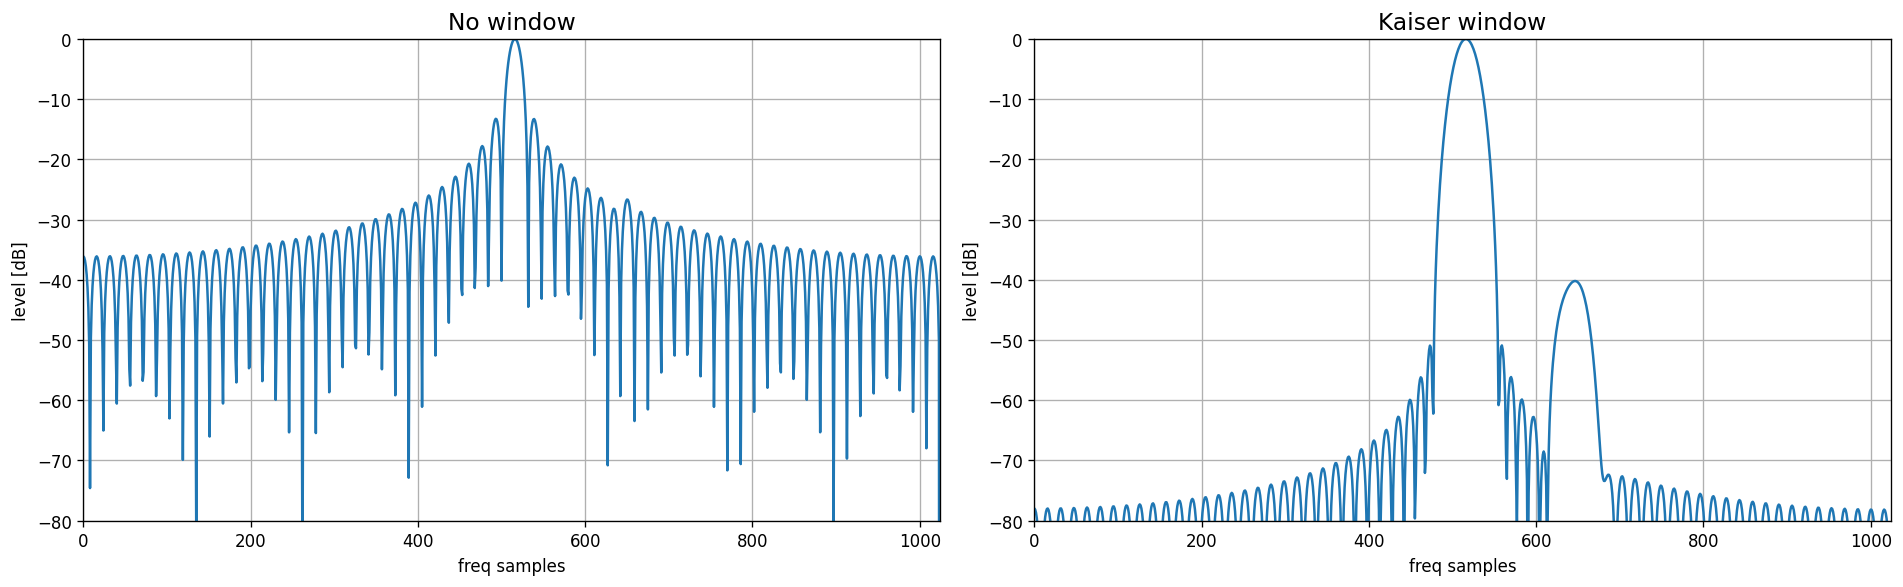

In [ ]:
#Поиск слабых сигналов
N = 128
NFFT = 2048

# Input signal (long: N >> NFFT)
tt = np.linspace(0, 1, N, endpoint=True)
xx = 100*np.cos(2*np.pi*32*tt)+np.cos(2*np.pi*40*tt)

# Window (Kaiser)
wn = sig.kaiser(N, beta=7)
yy = xx*wn

# Calculate FFT 1
sft = np.abs(fft(xx, NFFT))
slg = 20*np.log10(sft / np.max(sft))

# Calculate FFT 2
yft = np.abs(fft(yy, NFFT))
ylg = 20*np.log10(yft / np.max(yft))

lst_ffts = [slg, ylg]
lst_wins = ['No window', 'Kaiser window']
plt.figure(figsize=(16, 5), dpi=120)
for i in range(2):
    plt.subplot(1,2,i+1)
    plt.title(lst_wins[i], fontsize=14)
    plt.xlabel('freq samples')
    plt.ylabel('level [dB]')
    plt.plot(lst_ffts[i])
    plt.xlim([0, NFFT//2])
    plt.ylim([-80, 0])
    plt.grid(True)
plt.tight_layout()